**TASK-2:Create a K-means clustering algorithm to group customers of a retail store based on their purchase history.**

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9

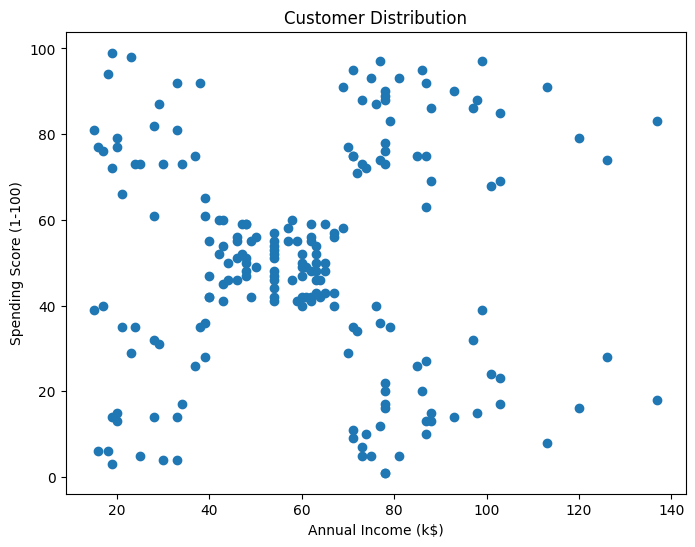

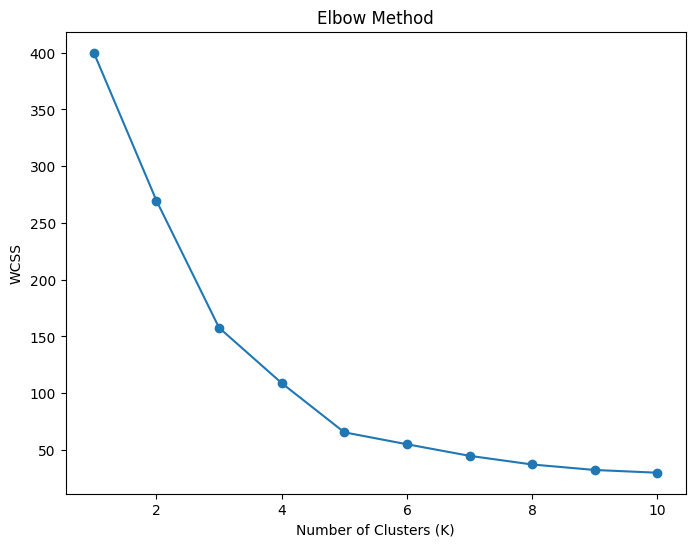


Silhouette Score: 0.5546571631111091

Customer Segments:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17                      40   
5            6  Female   22                  17                      76   
6            7  Female   35                  18                       6   
7            8  Female   23                  18                      94   
8            9    Male   64                  19                       3   
9           10  Female   30                  19                      72   
10          11    Male   67                  19                      14   
11          12  Female   35               

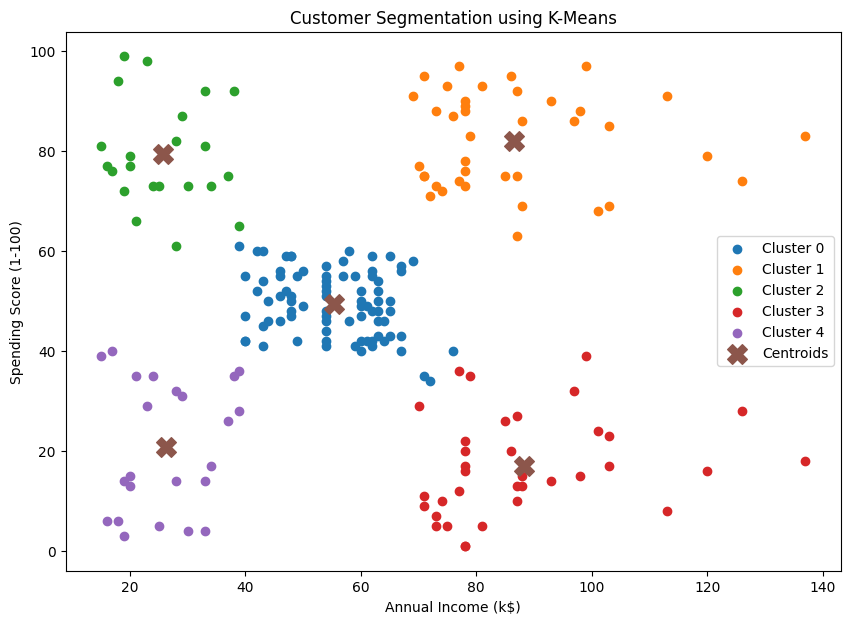


Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                          
0        42.716049           55.296296               49.518519   
1        32.692308           86.538462               82.128205   
2        25.272727           25.727273               79.363636   
3        41.114286           88.200000               17.114286   
4        45.217391           26.304348               20.913043   

         Number of Customers  
Cluster                       
0                         81  
1                         39  
2                         22  
3                         35  
4                         23  

New Customer:
Annual Income: $70,000
Spending Score: 80
Assigned Cluster: 1


In [ ]:
# Customer Segmentation using K-Means Clustering

# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# 2. Load the dataset
df = pd.read_csv("Mall_Customers.csv")


# 3. Display the dataset
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# 4. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# 5. Select features for clustering
# Annual Income = income of customer in thousands of dollars
# Spending Score = score based on customer's spending behavior

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]


# 6. Visualize the original data
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")

plt.show()


# 7. Standardize the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# 8. Find the optimal number of clusters using Elbow Method

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


# 9. Plot Elbow Curve
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


# 10. Create the K-Means model
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)


# 11. Train the model and assign clusters
df["Cluster"] = kmeans.fit_predict(X_scaled)


# 12. Calculate Silhouette Score
silhouette = silhouette_score(X_scaled, df["Cluster"])

print("\nSilhouette Score:", silhouette)


# 13. Display customers with their cluster
print("\nCustomer Segments:")
print(
    df[
        [
            "CustomerID",
            "Gender",
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)",
            "Cluster"
        ]
    ].head(20)
)


# 14. Get cluster centers
centers_scaled = kmeans.cluster_centers_

# Convert centers back to original scale
centers = scaler.inverse_transform(centers_scaled)

print("\nCluster Centers:")
print(centers)


# 15. Visualize the clusters

plt.figure(figsize=(10, 7))

for cluster in range(5):

    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}"
    )


# Plot cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    marker="X",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.legend()
plt.show()


# 16. Analyze each cluster

cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
})

cluster_summary.rename(
    columns={
        "CustomerID": "Number of Customers"
    },
    inplace=True
)

print("\nCluster Summary:")
print(cluster_summary)


# 17. Predict cluster for a new customer

# Example:
# Annual income = 70k
# Spending score = 80

new_customer = pd.DataFrame({
    "Annual Income (k$)": [70],
    "Spending Score (1-100)": [80]
})

new_customer_scaled = scaler.transform(new_customer)

new_cluster = kmeans.predict(new_customer_scaled)

print("\nNew Customer:")
print("Annual Income: $70,000")
print("Spending Score: 80")
print("Assigned Cluster:", new_cluster[0])